<a href="https://colab.research.google.com/github/swethasri9423-glitch/AI-Project-Failure-Predictor/blob/main/AI_Viva_Examiner_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 AI EXAMINER VIVA AGENT

## RAG + AI Agent Based Viva Examination System

### Project Objective
The AI Examiner Viva Agent is an intelligent viva examination system that uses
Retrieval-Augmented Generation (RAG) and AI Agent concepts to conduct,
evaluate, and manage viva examinations.

### Main Features
- 📚 Retrieval-Augmented Generation (RAG)
- 🤖 AI Agent workflow
- ❓ Automatic viva question selection
- 📝 Student answer evaluation
- 💡 AI-generated feedback
- 🔄 Adaptive follow-up questions
- 🧠 Agent memory
- 👨‍🏫 Human-in-the-loop review
- 📊 Performance analysis
- 🔍 Execution trace / observability

### Architecture

Student
   ↓
AI Examiner Agent
   ↓
Question Selection
   ↓
RAG Retrieval
   ↓
Answer Evaluation
   ↓
Feedback Generation
   ↓
Adaptive Follow-up
   ↓
Memory
   ↓
Human Review

### Technologies
Python | Google Colab | Pandas | Scikit-learn | TF-IDF | Cosine Similarity | RAG | AI Agents

In [1]:
!pip -q install pypdf scikit-learn pandas matplotlib reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.0 MB/s eta 0:00:00


In [2]:
# CELL 3 — Imports

import os
import re
import json
import random
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from IPython.display import display, Markdown

print("✅ AI Examiner Viva Agent libraries imported successfully!")

✅ AI Examiner Viva Agent libraries imported successfully!


In [3]:
# CELL 4 — RAG Knowledge Base

knowledge_base = [
    {
        "title": "Artificial Intelligence",
        "text": """
        Artificial Intelligence is the field of creating computer systems
        that can perform tasks requiring human-like intelligence.
        These tasks include reasoning, learning, perception,
        problem solving and decision making.
        """
    },

    {
        "title": "Machine Learning",
        "text": """
        Machine Learning is a subset of Artificial Intelligence.
        It enables computers to learn patterns from data and make
        predictions or decisions without explicitly programming
        every possible rule.
        """
    },

    {
        "title": "Retrieval Augmented Generation",
        "text": """
        Retrieval-Augmented Generation, or RAG, combines information
        retrieval with text generation. A retriever searches a knowledge
        base for relevant information. The retrieved information is then
        provided as context to generate a more grounded answer.
        """
    },

    {
        "title": "AI Agents",
        "text": """
        An AI agent is a system that works toward a goal by observing
        information, making decisions, selecting actions and using tools.
        An agent can plan a workflow and evaluate the results of its actions.
        """
    },

    {
        "title": "Vector Retrieval",
        "text": """
        Vector retrieval represents text numerically so that similarity
        between a query and documents can be calculated. TF-IDF is a
        traditional text representation method and cosine similarity
        can be used to compare vectors.
        """
    },

    {
        "title": "Human in the Loop",
        "text": """
        Human-in-the-loop means that a human can review, approve,
        correct or reject an AI-generated result. It provides additional
        control and improves reliability for important decisions.
        """
    },

    {
        "title": "Agent Memory",
        "text": """
        Agent memory stores information from previous interactions.
        In a viva system, memory can store questions, student answers,
        scores and feedback so that previous performance can be analyzed.
        """
    }
]

documents = [item["text"] for item in knowledge_base]

print("✅ Knowledge base created!")
print("Number of documents:", len(knowledge_base))

✅ Knowledge base created!
Number of documents: 7


In [4]:
# CELL 5 — Build RAG Retrieval System

vectorizer = TfidfVectorizer(stop_words="english")

doc_vectors = vectorizer.fit_transform(documents)

print("✅ TF-IDF vector database created!")
print("Vector shape:", doc_vectors.shape)

✅ TF-IDF vector database created!
Vector shape: (7, 107)


In [5]:
# CELL 6 — RAG Retriever Function

def retrieve_context(query, top_k=3):

    query_vector = vectorizer.transform([query])

    similarity_scores = cosine_similarity(
        query_vector,
        doc_vectors
    )[0]

    ranked_indices = similarity_scores.argsort()[::-1][:top_k]

    results = []

    for index in ranked_indices:

        results.append({
            "title": knowledge_base[index]["title"],
            "text": knowledge_base[index]["text"],
            "score": round(float(similarity_scores[index]), 4)
        })

    return results


# Test RAG
query = "What is Retrieval Augmented Generation?"

results = retrieve_context(query)

print("🔍 Retrieved Context:\n")

for result in results:

    print("Topic:", result["title"])
    print("Similarity:", result["score"])
    print(result["text"])
    print("-" * 60)

🔍 Retrieved Context:

Topic: Retrieval Augmented Generation
Similarity: 0.5238

        Retrieval-Augmented Generation, or RAG, combines information
        retrieval with text generation. A retriever searches a knowledge
        base for relevant information. The retrieved information is then
        provided as context to generate a more grounded answer.
        
------------------------------------------------------------
Topic: Vector Retrieval
Similarity: 0.0887

        Vector retrieval represents text numerically so that similarity
        between a query and documents can be calculated. TF-IDF is a
        traditional text representation method and cosine similarity
        can be used to compare vectors.
        
------------------------------------------------------------
Topic: Agent Memory
Similarity: 0.0

        Agent memory stores information from previous interactions.
        In a viva system, memory can store questions, student answers,
        scores and feedback so 

In [6]:
# CELL 7 — Viva Question Bank

question_bank = [

    {
        "id": 1,
        "topic": "RAG",
        "difficulty": "Easy",
        "question": "What is Retrieval-Augmented Generation?",
        "concepts": ["retrieval", "knowledge", "context", "generation"],
        "reference": "RAG retrieves relevant information from a knowledge base and uses it as context for generating a grounded answer."
    },

    {
        "id": 2,
        "topic": "RAG",
        "difficulty": "Medium",
        "question": "Why is RAG useful in an AI application?",
        "concepts": ["external knowledge", "retrieval", "context", "hallucination"],
        "reference": "RAG provides external or domain-specific information and can reduce unsupported responses."
    },

    {
        "id": 3,
        "topic": "AI Agent",
        "difficulty": "Easy",
        "question": "What is an AI Agent?",
        "concepts": ["goal", "decision", "tools", "action"],
        "reference": "An AI agent works toward a goal by making decisions and using tools or actions."
    },

    {
        "id": 4,
        "topic": "AI Agent",
        "difficulty": "Medium",
        "question": "How does your AI Examiner Viva Agent work?",
        "concepts": ["question", "retrieval", "evaluation", "feedback", "follow-up"],
        "reference": "The agent selects a question, retrieves relevant context, evaluates the answer, generates feedback and selects a follow-up question."
    },

    {
        "id": 5,
        "topic": "Retrieval",
        "difficulty": "Medium",
        "question": "How does TF-IDF help in your RAG system?",
        "concepts": ["TF-IDF", "vector", "text", "similarity"],
        "reference": "TF-IDF converts text into numerical vectors so that similarity between queries and documents can be calculated."
    },

    {
        "id": 6,
        "topic": "Retrieval",
        "difficulty": "Medium",
        "question": "What is cosine similarity?",
        "concepts": ["cosine", "similarity", "vectors", "angle"],
        "reference": "Cosine similarity measures how similar two vectors are by comparing the angle between them."
    },

    {
        "id": 7,
        "topic": "Memory",
        "difficulty": "Medium",
        "question": "Why is memory useful for an AI Agent?",
        "concepts": ["history", "previous", "score", "feedback"],
        "reference": "Memory stores previous interactions, scores and feedback so future decisions can use historical information."
    },

    {
        "id": 8,
        "topic": "Human in the Loop",
        "difficulty": "Easy",
        "question": "What is Human-in-the-Loop?",
        "concepts": ["human", "review", "approval", "control"],
        "reference": "Human-in-the-loop allows a human to review or approve AI-generated results."
    },

    {
        "id": 9,
        "topic": "Limitations",
        "difficulty": "Hard",
        "question": "What are the limitations of your AI Examiner Viva Agent?",
        "concepts": ["knowledge base", "retrieval", "evaluation", "subjective"],
        "reference": "The system depends on knowledge quality, retrieval quality and the accuracy of automated answer evaluation."
    }

]

question_df = pd.DataFrame(question_bank)

print("✅ Viva question bank created!")
print("Total questions:", len(question_bank))

display(
    question_df[
        ["id", "topic", "difficulty", "question"]
    ]
)

✅ Viva question bank created!
Total questions: 9


,id,topic,difficulty,question
0,1,RAG,Easy,What is Retrieval-Augmented Generation?
1,2,RAG,Medium,Why is RAG useful in an AI application?
2,3,AI Agent,Easy,What is an AI Agent?
3,4,AI Agent,Medium,How does your AI Examiner Viva Agent work?
4,5,Retrieval,Medium,How does TF-IDF help in your RAG system?
5,6,Retrieval,Medium,What is cosine similarity?
6,7,Memory,Medium,Why is memory useful for an AI Agent?
7,8,Human in the Loop,Easy,What is Human-in-the-Loop?
8,9,Limitations,Hard,What are the limitations of your AI Examiner V...


In [7]:
# CELL 8 — AI Agent Tools

execution_trace = []

viva_memory = []


def log_step(action, details=""):

    execution_trace.append({
        "step": len(execution_trace) + 1,
        "action": action,
        "details": details
    })


def select_question(topic=None, difficulty=None):

    candidates = question_bank.copy()

    if topic:
        filtered = [
            q for q in candidates
            if q["topic"].lower() == topic.lower()
        ]

        if filtered:
            candidates = filtered

    if difficulty:
        filtered = [
            q for q in candidates
            if q["difficulty"].lower() == difficulty.lower()
        ]

        if filtered:
            candidates = filtered

    return random.choice(candidates)


print("✅ Question Selection Tool created!")
print("✅ Agent Memory created!")
print("✅ Execution Trace created!")

✅ Question Selection Tool created!
✅ Agent Memory created!
✅ Execution Trace created!


In [8]:
# CELL 9 — Answer Evaluation Tool

def evaluate_answer(answer, question, context):

    answer_lower = answer.lower()

    concept_hits = []

    for concept in question["concepts"]:

        if concept.lower() in answer_lower:
            concept_hits.append(concept)

    # Concept coverage score
    concept_score = (
        len(concept_hits)
        / len(question["concepts"])
    ) * 10

    # Compare answer with retrieved RAG context
    context_text = " ".join(
        item["text"] for item in context
    )

    answer_vector = vectorizer.transform([answer])
    context_vector = vectorizer.transform([context_text])

    similarity = float(
        cosine_similarity(
            answer_vector,
            context_vector
        )[0][0]
    )

    # Final score
    final_score = (
        concept_score * 0.75
        +
        similarity * 10 * 0.25
    )

    final_score = min(
        10,
        round(final_score, 1)
    )

    if final_score >= 8:
        level = "Excellent"

    elif final_score >= 6:
        level = "Good"

    elif final_score >= 4:
        level = "Needs Improvement"

    else:
        level = "Weak"

    return {
        "score": final_score,
        "level": level,
        "concept_hits": concept_hits,
        "retrieval_similarity": round(similarity, 3)
    }


print("✅ Answer Evaluation Tool created!")

✅ Answer Evaluation Tool created!


In [9]:
# CELL 10 — Feedback and Adaptive Follow-up

def generate_feedback(evaluation, question):

    missing = [
        concept
        for concept in question["concepts"]
        if concept not in evaluation["concept_hits"]
    ]

    score = evaluation["score"]

    if score >= 8:

        feedback = (
            "Excellent answer. You covered the important "
            "concepts clearly."
        )

    elif score >= 6:

        feedback = (
            "Good answer. Add more technical explanation "
            "and a practical example."
        )

    elif score >= 4:

        feedback = (
            "Your answer is partially correct. "
            "Explain the concept more systematically."
        )

    else:

        feedback = (
            "The answer needs improvement. "
            "Start with the definition, explain the workflow "
            "and then give an example."
        )

    if missing:

        feedback += (
            " Important concepts that were missing or unclear: "
            + ", ".join(missing)
            + "."
        )

    return feedback


def generate_follow_up(evaluation, current_question):

    score = evaluation["score"]

    if score >= 8:
        target_difficulty = "Hard"

    elif score >= 6:
        target_difficulty = "Medium"

    else:
        target_difficulty = "Easy"

    candidates = [
        q for q in question_bank
        if q["topic"] == current_question["topic"]
        and q["id"] != current_question["id"]
    ]

    same_level = [
        q for q in candidates
        if q["difficulty"] == target_difficulty
    ]

    if same_level:
        return random.choice(same_level)

    if candidates:
        return random.choice(candidates)

    return random.choice(question_bank)


print("✅ Feedback Generator created!")
print("✅ Adaptive Follow-up Tool created!")

✅ Feedback Generator created!
✅ Adaptive Follow-up Tool created!


In [10]:
# CELL 11 — Agent Memory Tool

def save_viva_memory(
    question,
    answer,
    evaluation,
    feedback
):

    viva_memory.append({

        "question": question["question"],

        "topic": question["topic"],

        "difficulty": question["difficulty"],

        "score": evaluation["score"],

        "level": evaluation["level"],

        "answer": answer,

        "feedback": feedback
    })


print("✅ Memory Tool created!")

✅ Memory Tool created!


In [11]:
# CELL 12 — MAIN AI EXAMINER VIVA AGENT

def run_viva_agent(question, student_answer):

    global execution_trace

    execution_trace = []

    # STEP 1 — Question
    log_step(
        "Question Selection",
        question["question"]
    )

    # STEP 2 — RAG Retrieval
    context = retrieve_context(
        question["question"],
        top_k=3
    )

    log_step(
        "RAG Retrieval",
        f"Retrieved {len(context)} relevant documents"
    )

    # STEP 3 — Evaluation
    evaluation = evaluate_answer(
        student_answer,
        question,
        context
    )

    log_step(
        "Answer Evaluation",
        f"Score = {evaluation['score']}/10"
    )

    # STEP 4 — Feedback
    feedback = generate_feedback(
        evaluation,
        question
    )

    log_step(
        "Feedback Generation",
        "Generated feedback for student"
    )

    # STEP 5 — Adaptive Follow-up
    follow_up = generate_follow_up(
        evaluation,
        question
    )

    log_step(
        "Adaptive Planning",
        follow_up["question"]
    )

    # STEP 6 — Memory
    save_viva_memory(
        question,
        student_answer,
        evaluation,
        feedback
    )

    log_step(
        "Memory Update",
        "Viva attempt saved"
    )

    return {

        "question": question,

        "student_answer": student_answer,

        "retrieved_context": context,

        "evaluation": evaluation,

        "feedback": feedback,

        "follow_up": follow_up
    }


print("🤖 AI EXAMINER VIVA AGENT IS READY!")

🤖 AI EXAMINER VIVA AGENT IS READY!


In [12]:
# CELL 13 — Test the AI Examiner

question = question_bank[0]

student_answer = """
RAG stands for Retrieval-Augmented Generation.
It retrieves relevant information from a knowledge base
and provides that information as context for generating
a grounded answer.
"""

result = run_viva_agent(
    question,
    student_answer
)

print("=" * 60)
print("🎓 AI EXAMINER VIVA RESULT")
print("=" * 60)

print("\nQUESTION:")
print(result["question"]["question"])

print("\nSTUDENT ANSWER:")
print(result["student_answer"])

print("\nRAG RETRIEVED CONTEXT:")

for item in result["retrieved_context"]:

    print(
        f"• {item['title']} "
        f"(similarity: {item['score']})"
    )

print("\nSCORE:")
print(
    result["evaluation"]["score"],
    "/ 10"
)

print("\nLEVEL:")
print(
    result["evaluation"]["level"]
)

print("\nFEEDBACK:")
print(
    result["feedback"]
)

print("\nNEXT ADAPTIVE QUESTION:")
print(
    result["follow_up"]["question"]
)

🎓 AI EXAMINER VIVA RESULT

QUESTION:
What is Retrieval-Augmented Generation?

STUDENT ANSWER:

RAG stands for Retrieval-Augmented Generation.
It retrieves relevant information from a knowledge base
and provides that information as context for generating
a grounded answer.


RAG RETRIEVED CONTEXT:
• Retrieval Augmented Generation (similarity: 0.5238)
• Vector Retrieval (similarity: 0.0887)
• Agent Memory (similarity: 0.0)

SCORE:
8.8 / 10

LEVEL:
Excellent

FEEDBACK:
Excellent answer. You covered the important concepts clearly.

NEXT ADAPTIVE QUESTION:
Why is RAG useful in an AI application?


In [13]:
# CELL 14 — Human-in-the-Loop Review

def human_review(result):

    print("=" * 60)
    print("👨‍🏫 HUMAN REVIEW")
    print("=" * 60)

    print("\nAI SCORE:")
    print(result["evaluation"]["score"], "/ 10")

    print("\nAI LEVEL:")
    print(result["evaluation"]["level"])

    print("\nAI FEEDBACK:")
    print(result["feedback"])

    decision = input(
        "\nHuman Reviewer — type APPROVE or REVISE: "
    ).strip().upper()

    if decision == "APPROVE":
        print("\n✅ Evaluation approved by human reviewer.")

    else:
        print("\n🔄 Evaluation marked for revision.")

    return decision


# To use human review, run:
# human_review(result)

In [14]:
# CELL 15 — Execution Trace

trace_df = pd.DataFrame(execution_trace)

print("🔍 AI AGENT EXECUTION TRACE")
print("=" * 60)

display(trace_df)

🔍 AI AGENT EXECUTION TRACE


,step,action,details
0,1,Question Selection,What is Retrieval-Augmented Generation?
1,2,RAG Retrieval,Retrieved 3 relevant documents
2,3,Answer Evaluation,Score = 8.8/10
3,4,Feedback Generation,Generated feedback for student
4,5,Adaptive Planning,Why is RAG useful in an AI application?
5,6,Memory Update,Viva attempt saved


In [15]:
# CELL 16 — Display Agent Memory

memory_df = pd.DataFrame(viva_memory)

print("🧠 VIVA AGENT MEMORY")
print("=" * 60)

if len(memory_df) > 0:
    display(memory_df)

else:
    print("No viva attempts stored yet.")

🧠 VIVA AGENT MEMORY


,question,topic,difficulty,score,level,answer,feedback
0,What is Retrieval-Augmented Generation?,RAG,Easy,8.8,Excellent,\nRAG stands for Retrieval-Augmented Generatio...,Excellent answer. You covered the important co...


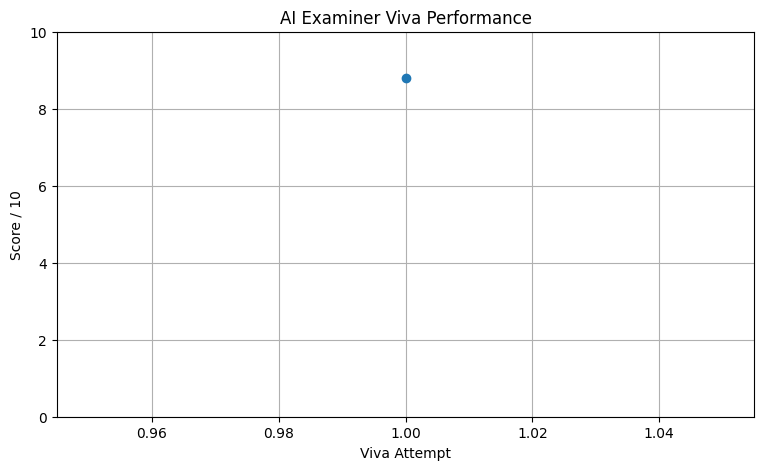

In [16]:
# CELL 17 — Student Performance Analysis

if len(viva_memory) > 0:

    performance_df = pd.DataFrame(viva_memory)

    plt.figure(figsize=(9, 5))

    plt.plot(
        range(1, len(performance_df) + 1),
        performance_df["score"],
        marker="o"
    )

    plt.xlabel("Viva Attempt")
    plt.ylabel("Score / 10")
    plt.title("AI Examiner Viva Performance")

    plt.ylim(0, 10)
    plt.grid(True)

    plt.show()

else:

    print("Run some viva questions first.")

In [18]:
# CELL 18 — Interactive Viva Mode

def interactive_viva():

    print("=" * 60)
    print("🎓 AI EXAMINER VIVA AGENT")
    print("=" * 60)

    topic = input(
        "\nEnter topic "
        "(RAG / AI Agent / Retrieval / Memory / Human in the Loop / Limitations)"
        "\nPress Enter for any topic: "
    ).strip()

    difficulty = input(
        "\nEnter difficulty "
        "(Easy / Medium / Hard)"
        "\nPress Enter for any difficulty: "
    ).strip()

    question = select_question(
        topic if topic else None,
        difficulty if difficulty else None
    )

    print("\n" + "=" * 60)
    print("❓ VIVA QUESTION")
    print("=" * 60)

    print(question["question"])

    student_answer = input(
        "\n🧑‍🎓 Your Answer: "
    )

    result = run_viva_agent(
        question,
        student_answer
    )

    print("\n" + "=" * 60)
    print("📋 EXAMINER RESULT")
    print("=" * 60)

    print(
        "\nScore:",
        result["evaluation"]["score"],
        "/ 10"
    )

    print(
        "Level:",
        result["evaluation"]["level"]
    )

    print(
        "\n💡 Feedback:"
    )

    print(
        result["feedback"]
    )

    print(
        "\n🔄 Follow-up Question:"
    )

    print(
        result["follow_up"]["question"]
    )


# START THE VIVA:
interactive_viva()

🎓 AI EXAMINER VIVA AGENT

Enter topic (RAG / AI Agent / Retrieval / Memory / Human in the Loop / Limitations)
Press Enter for any topic: RAG

Enter difficulty (Easy / Medium / Hard)
Press Enter for any difficulty: Easy

❓ VIVA QUESTION
What is Retrieval-Augmented Generation?

🧑‍🎓 Your Answer: RAG stands for Retrieval-Augmented Generation. It retrieves relevant information from a knowledge base and provides that information as context to generate a more accurate and grounded answer.

📋 EXAMINER RESULT

Score: 8.8 / 10
Level: Excellent

💡 Feedback:
Excellent answer. You covered the important concepts clearly.

🔄 Follow-up Question:
Why is RAG useful in an AI application?


In [19]:
# CELL 19 — Final Project Summary

print("=" * 70)
print("🎓 AI EXAMINER VIVA AGENT")
print("=" * 70)

print("""
PROJECT TYPE:
RAG + AI Agent

MAIN COMPONENTS:

1. RAG Knowledge Base
   → Stores AI and project-related information.

2. Retrieval System
   → Uses TF-IDF and Cosine Similarity.

3. Question Selection Agent
   → Selects questions based on topic and difficulty.

4. Answer Evaluation Agent
   → Evaluates the student's answer.

5. Feedback Generator
   → Provides personalized feedback.

6. Adaptive Follow-up Agent
   → Selects the next question based on performance.

7. Agent Memory
   → Stores previous viva attempts.

8. Human-in-the-Loop
   → Allows a teacher/human to review the AI evaluation.

9. Execution Trace
   → Shows the sequence of agent actions.

10. Performance Analysis
    → Visualizes viva scores.

WORKFLOW:

Student
   ↓
AI Examiner Agent
   ↓
Question Selection
   ↓
RAG Retrieval
   ↓
Answer Evaluation
   ↓
Feedback
   ↓
Adaptive Follow-up
   ↓
Memory
   ↓
Human Review
""")

🎓 AI EXAMINER VIVA AGENT

PROJECT TYPE:
RAG + AI Agent

MAIN COMPONENTS:

1. RAG Knowledge Base
   → Stores AI and project-related information.

2. Retrieval System
   → Uses TF-IDF and Cosine Similarity.

3. Question Selection Agent
   → Selects questions based on topic and difficulty.

4. Answer Evaluation Agent
   → Evaluates the student's answer.

5. Feedback Generator
   → Provides personalized feedback.

6. Adaptive Follow-up Agent
   → Selects the next question based on performance.

7. Agent Memory
   → Stores previous viva attempts.

8. Human-in-the-Loop
   → Allows a teacher/human to review the AI evaluation.

9. Execution Trace
   → Shows the sequence of agent actions.

10. Performance Analysis
    → Visualizes viva scores.

WORKFLOW:

Student
   ↓
AI Examiner Agent
   ↓
Question Selection
   ↓
RAG Retrieval
   ↓
Answer Evaluation
   ↓
Feedback
   ↓
Adaptive Follow-up
   ↓
Memory
   ↓
Human Review

